# STATS 601 Project: Single-cell RNA-seq Classification
**Author:** Kenny Chen
**Dataset:** PBMC 3k (10x Genomics)

This notebook contains the data preprocessing, model training, and visualization code for the $2 \times 2$ experimental design evaluating Logistic Regression and Random Forest on standard vs. binarized scRNA-seq data.

In [1]:

!pip install scanpy

import scanpy as sc
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore') 

# Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

print(f"Data matrix shape (cells x genes): {adata.shape}")
adata.obs.head() 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 22.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: umap-learn
    Found existing installation: umap-learn 0.5.11
    Uninstalling umap-learn-0.5.11:
      Successfully uninstalled umap-learn-0.5.11


  0%|          | 0.00/23.5M [00:00<?, ?B/s]

Data matrix shape (cells x genes): (2638, 1838)


,n_genes,percent_mito,n_counts,louvain
index,,,,
AAACATACAACCAC-1,781,0.030178,2419.0,CD4 T cells
AAACATTGAGCTAC-1,1352,0.037936,4903.0,B cells
AAACATTGATCAGC-1,1131,0.008897,3147.0,CD4 T cells
AAACCGTGCTTCCG-1,960,0.017431,2639.0,CD14+ Monocytes
AAACCGTGTATGCG-1,522,0.012245,980.0,NK cells


### 1. Data Parsing and Label Encoding
Extracting the raw count matrix and assigning integer labels to cell types.

In [2]:
from sklearn.preprocessing import LabelEncoder

# Extract feature matrix X
if hasattr(adata.raw.X, 'toarray'):
    X_raw = adata.raw.X.toarray()
else:
    X_raw = adata.raw.X

# Extract target labels y 
y_labels = adata.obs['louvain'].values

encoder = LabelEncoder()
y = encoder.fit_transform(y_labels)

print(f"X shape: {X_raw.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {encoder.classes_}")

X shape: (2638, 13714)
y shape: (2638,)
Classes: ['B cells' 'CD14+ Monocytes' 'CD4 T cells' 'CD8 T cells' 'Dendritic cells'
 'FCGR3A+ Monocytes' 'Megakaryocytes' 'NK cells']


### 2. Preprocessing Strategies Validation
Comparing Raw Counts, Log-transformation, and Binarization using Logistic Regression as a baseline.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# Create variations of the dataset
datasets = {
    "Raw Counts": X_raw.copy(),
    "Log-Transformed": np.log1p(X_raw),
    "Binarized": (X_raw > 0).astype(float)
}

# Evaluate basic Logistic Regression on different pipelines
for name, X_data in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42, stratify=y
    )
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    
    start_time = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    print(f"[{name}] Test Acc: {test_acc:.4f} | Time: {train_time:.2f}s")

[Raw Counts] Test Acc: 0.9280 | Time: 9.26s
[Log-Transformed] Test Acc: 0.9223 | Time: 7.78s
[Binarized] Test Acc: 0.9205 | Time: 4.76s


### 3. The 2x2 Experimental Design
Evaluating the interaction between model capacity (Linear vs. Non-linear) and preprocessing.

In [5]:
from sklearn.ensemble import RandomForestClassifier

exp_datasets = {
    "Log-Transformed": np.log1p(X_raw),
    "Binarized": (X_raw > 0).astype(float)
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for data_name, X_data in exp_datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42, stratify=y
    )
    
    for model_name, clf in models.items():
        start_time = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        print(f"Data: {data_name:<15} | Model: {model_name:<20} | Acc: {test_acc:.4f} | Time: {train_time:.2f}s")

Data: Log-Transformed | Model: Logistic Regression  | Acc: 0.9223 | Time: 7.94s
Data: Log-Transformed | Model: Random Forest        | Acc: 0.9053 | Time: 2.55s
Data: Binarized       | Model: Logistic Regression  | Acc: 0.9205 | Time: 5.23s
Data: Binarized       | Model: Random Forest        | Acc: 0.8674 | Time: 2.55s


### 4. Biological Interpretability & Visualization
Extracting marker genes using the weights of the Logistic Regression model, followed by PCA and accuracy visualizations.

Top 5 marker genes extracted for B cells:
  CD79A (Weight: 0.3350)
  MS4A1 (Weight: 0.3072)
  HLA-DQA1 (Weight: 0.2756)
  HLA-DQB1 (Weight: 0.2557)
  CD79B (Weight: 0.2471)


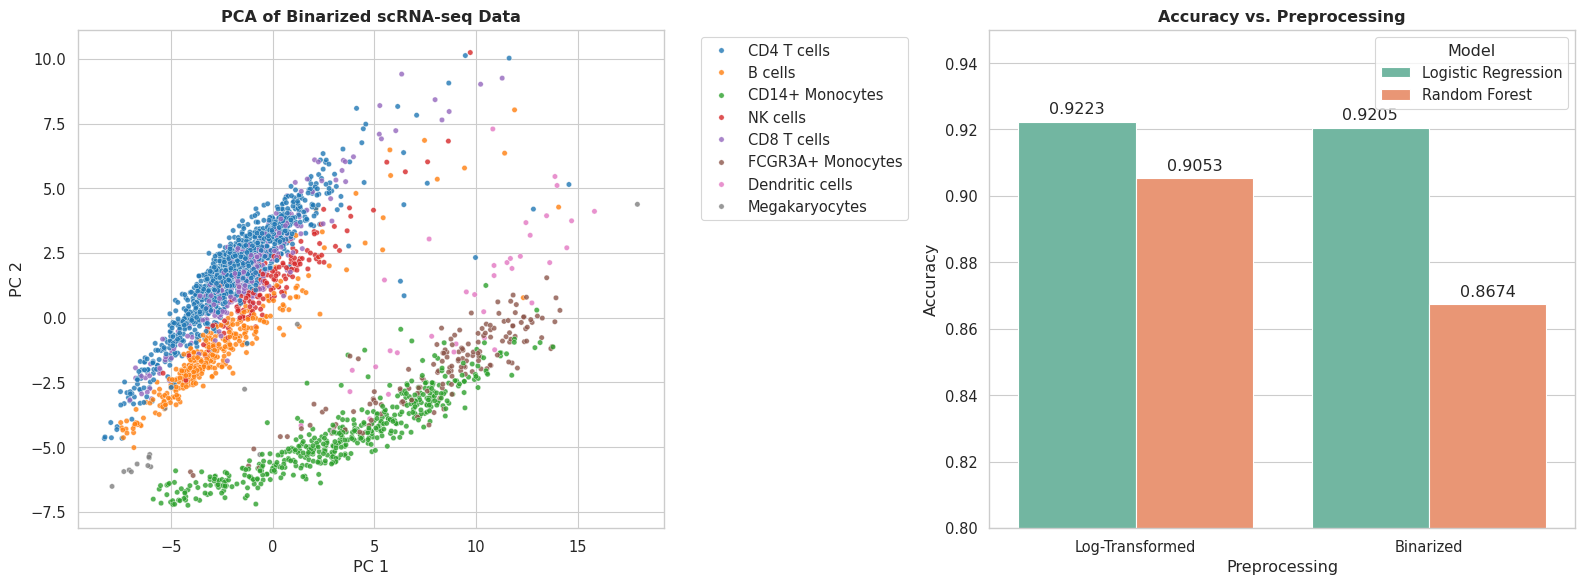

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Re-train the optimal model (Binarized + LR)
X_bin = (X_raw > 0).astype(float)
X_train_bin, X_test_bin, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.2, random_state=42, stratify=y
)
clf_best = LogisticRegression(max_iter=1000, random_state=42)
clf_best.fit(X_train_bin, y_train)

# Extract Marker Genes for B cells (Class Index 0)
gene_names = adata.raw.var_names.values
class_idx = 0 
class_name = encoder.classes_[class_idx]
weights = clf_best.coef_[class_idx]

top5_indices = np.argsort(weights)[-5:][::-1]
top5_genes = gene_names[top5_indices]

print(f"Top 5 marker genes extracted for {class_name}:")
for i, gene in enumerate(top5_genes):
    print(f"  {gene} (Weight: {weights[top5_indices[i]]:.4f})")

# ---------------- Visualizations ----------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_bin)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=encoder.inverse_transform(y), 
    palette="tab10", s=15, alpha=0.8, ax=axes[0]
)
axes[0].set_title("PCA of Binarized scRNA-seq Data", fontweight='bold')
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Performance Bar Chart
plot_data = pd.DataFrame({
    'Preprocessing': ['Log-Transformed', 'Log-Transformed', 'Binarized', 'Binarized'],
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.9223, 0.9053, 0.9205, 0.8674]
})

sns.barplot(
    data=plot_data, x='Preprocessing', y='Accuracy', 
    hue='Model', palette="Set2", ax=axes[1]
)
axes[1].set_title("Accuracy vs. Preprocessing", fontweight='bold')
axes[1].set_ylim(0.80, 0.95)
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

### 5. Advanced Diagnostics and Visualizations
Generating the confusion matrix, global feature importance, sparsity distribution, and marker gene validation plots to support the analytical findings in the main report.

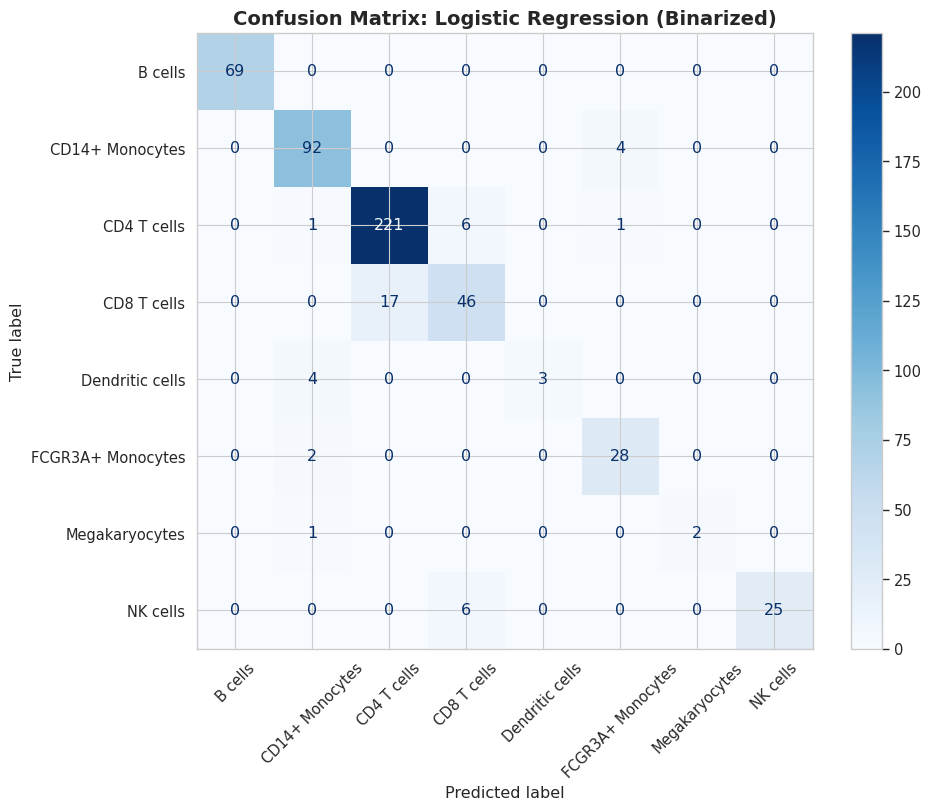

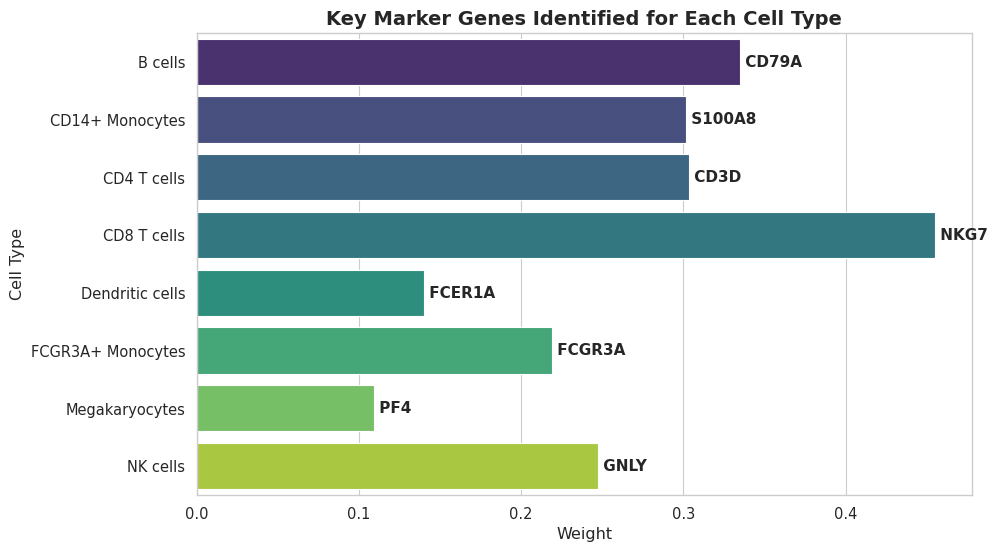

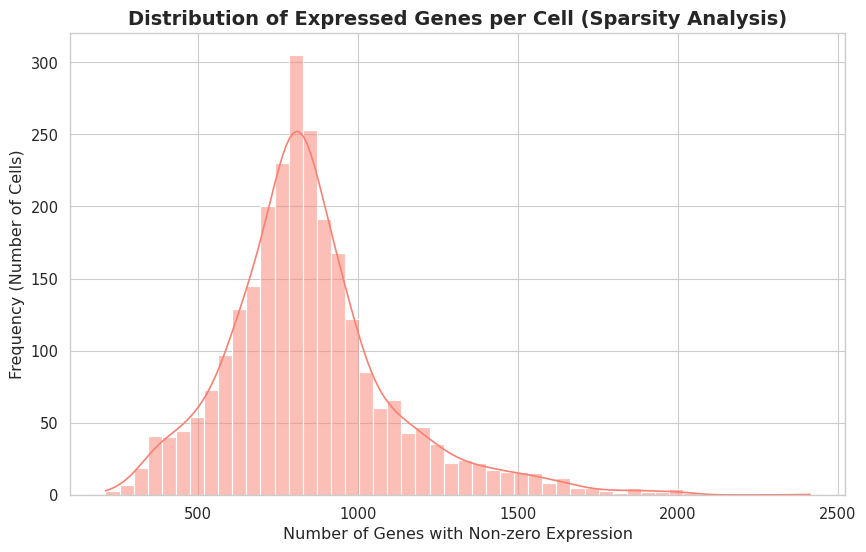

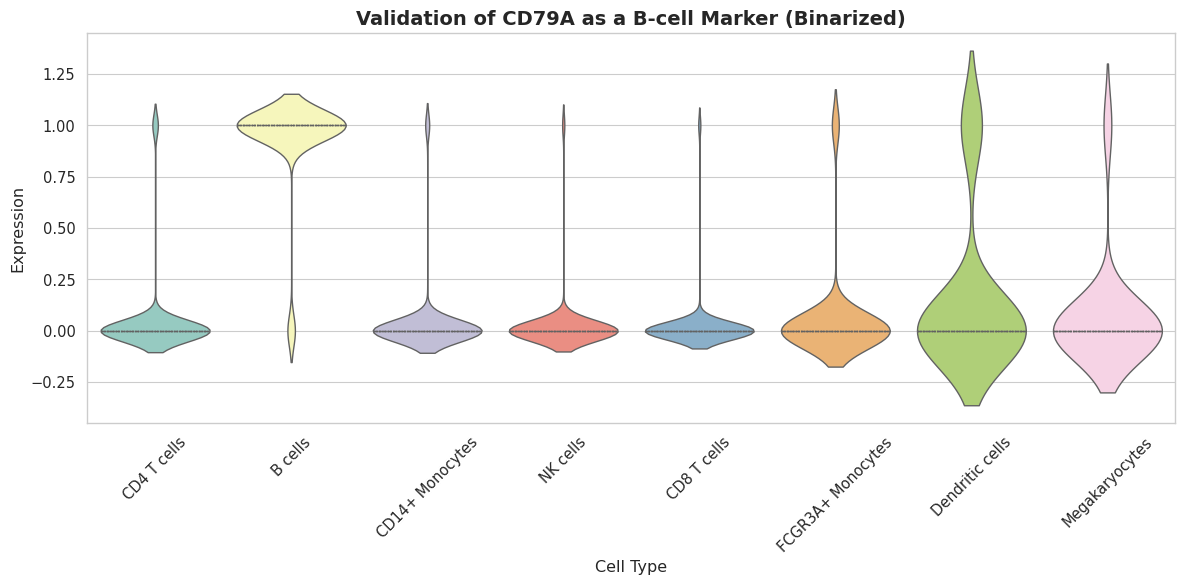

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

# 1. Confusion Matrix for the Best Model (Logistic Regression on Binarized Data)
y_pred = clf_best.predict(X_test_bin)
cm = confusion_matrix(y_test, y_pred)
fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', ax=ax_cm, xticks_rotation=45)
ax_cm.set_title("Confusion Matrix: Logistic Regression (Binarized)", fontsize=14, fontweight='bold')

# 2. Global Feature Importance (Top Genes for ALL Cell Types)
all_top_genes = []
for i, class_label in enumerate(encoder.classes_):
    weights = clf_best.coef_[i]
    top_idx = np.argmax(weights)
    all_top_genes.append({
        'Cell Type': class_label,
        'Top Gene': gene_names[top_idx],
        'Weight': weights[top_idx]
    })

df_importance = pd.DataFrame(all_top_genes)
fig_imp, ax_imp = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_importance, x='Weight', y='Cell Type', palette='viridis', ax=ax_imp)

for i, p in enumerate(ax_imp.patches):
    ax_imp.annotate(f" {df_importance.iloc[i]['Top Gene']}", 
                   (p.get_width(), p.get_y() + p.get_height()/2.),
                   ha='left', va='center', fontsize=11, fontweight='bold')
ax_imp.set_title("Key Marker Genes Identified for Each Cell Type", fontsize=14, fontweight='bold')

# 3. Data Sparsity Visualization (Distribution of Non-zero counts)
non_zero_counts = np.sum(X_raw > 0, axis=1)
fig_dist, ax_dist = plt.subplots(figsize=(10, 6))
sns.histplot(non_zero_counts, bins=50, kde=True, color='salmon', ax=ax_dist)
ax_dist.set_title("Distribution of Expressed Genes per Cell (Sparsity Analysis)", fontsize=14, fontweight='bold')
ax_dist.set_xlabel("Number of Genes with Non-zero Expression")
ax_dist.set_ylabel("Frequency (Number of Cells)")

# 4. Marker Gene Validation (Violin Plot for CD79A)
target_gene = "CD79A"
gene_idx = np.where(gene_names == target_gene)[0][0]
gene_expression = X_bin[:, gene_idx]

df_violin = pd.DataFrame({
    'Expression': gene_expression,
    'Cell Type': encoder.inverse_transform(y)
})

fig_vio, ax_vio = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_violin, x='Cell Type', y='Expression', inner="quartile", palette="Set3", ax=ax_vio)
ax_vio.set_title(f"Validation of {target_gene} as a B-cell Marker (Binarized)", fontsize=14, fontweight='bold')
ax_vio.set_xticklabels(ax_vio.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()